In [1]:
!pip install msprime tskit scikit-learn kmapper ripser matplotlib networkx plotly igraph ipywidgets persim -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 843.4/843.4 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 6.6 MB/s eta 0:00:00


In [2]:
import msprime
import tskit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS
from sklearn.decomposition import PCA
import kmapper as km
from kmapper.adapter import to_networkx
from ripser import Rips
from persim import plot_diagrams
import warnings
warnings.filterwarnings("ignore")

In [3]:
params = {
    'chrom_length':30000000,
    'recomb_rate':1e-8,
    'mut_rate':1.29e-8,
    'gen_time':29.0,
    'n_eu':100,
    'n_af':2,
    'n_nd':2,
    'ploidy':2
}
Ne = {
    'anc':18500,
    'nd':3400,
    'amh':23000,
    'ooa':1861,
    'af':27600,
    'eu':13377,
    'eu_bottleneck':1080,
    'eu_growth':1450
}
gen_time=params['gen_time']
t = {
    't_nd_migration':55000/gen_time,
    't_amh':550000/gen_time,
    't_ooa':65700/gen_time,
    't_nd_samples':38000/gen_time,
    't_eu_growth':31900/gen_time
}
t_second_wave=(55000-20000)/gen_time

In [4]:
def get_migrating_tracts_ind(ts,pop_name,ind_node,T_anc):
    pop_id=-1
    for p in ts.populations():
        if p.metadata.get('name')==pop_name:
            pop_id=p.id
            break
    if pop_id==-1:
        return []
    tables=ts.tables
    mask=((tables.migrations.time==T_anc)&(tables.migrations.dest==pop_id))
    relevant=np.where(mask)[0]
    mig_lookup={}
    for i in relevant:
        node=tables.migrations.node[i]
        interval=(tables.migrations.left[i],tables.migrations.right[i])
        mig_lookup.setdefault(node,[]).append(interval)
    tracts=[]
    for tree in ts.trees():
        anc=ind_node
        if ts.node(anc).time>T_anc:
            continue
        parent=tree.parent(anc)
        while (parent!=tskit.NULL and ts.node(parent).time<=T_anc):
            anc=parent
            parent=tree.parent(anc)
        if anc in mig_lookup:
            t_l,t_r=tree.interval
            for m_l,m_r in mig_lookup[anc]:
                s=max(t_l,m_l)
                e=min(t_r,m_r)
                if s<e:
                    if tracts and tracts[-1][1]==s:
                        tracts[-1][1]=e
                    else:
                        tracts.append([s,e])
    return tracts



In [5]:
def get_population_tracts_dataframe(ts, target_pop, source_pop, migration_time):
    t_id=-1
    for p in ts.populations():
        if p.metadata.get('name')==target_pop:
            t_id=p.id
            break
    nodes=ts.samples(population=t_id)
    if len(nodes)==0:
        return pd.DataFrame(columns=["Sample","Start","End","Length"])
    ind_ids=np.unique(ts.nodes_individual[nodes])
    ind_ids=ind_ids[ind_ids!=-1]
    data=[]
    for ind in ind_ids:
        individual=ts.individual(ind)
        for i,node in enumerate(individual.nodes):
            sample_name=f"{target_pop}_{ind}_{i+1}"
            tracts=get_migrating_tracts_ind(
                ts,
                source_pop,
                node,
                migration_time
            )
            for s,e in tracts:
                data.append({
                    "Sample":sample_name,
                    "Start":int(s),
                    "End":int(e),
                    "Length":int(e-s)
                })
    return pd.DataFrame(data)

In [6]:
def merge(intervals):
    if not intervals:
        return []
    intervals=sorted(intervals)
    res=[list(intervals[0])]
    for s,e in intervals[1:]:
        if s<=res[-1][1]:
            res[-1][1]=max(res[-1][1],e)
        else:
            res.append([s,e])
    return [(s,e) for s,e in res]


def get_tracts_dict(ts, n_eu, migration_times):
    tracts=defaultdict(list)
    for mig_time in migration_times:
        df=get_population_tracts_dataframe(ts, "EU", "ND", mig_time)
        for _,row in df.iterrows():
            ind=int(row['Sample'].split('_')[1])
            tracts[ind].append((row['Start'], row['End']))
    for i in range(n_eu):
        tracts[i]=merge(tracts[i])
    return tracts

In [7]:
def simulate_one_pulse(seed,admixture_prop=0.1):
    demography=msprime.Demography()
    for name,size in [("AF",Ne['af']),("EU",Ne['eu']),("AMH",Ne['amh']),
                      ("ND",Ne['nd']),("ANCES",Ne['anc']),("OOA",Ne['ooa'])]:
        demography.add_population(name=name, initial_size=size)

    demography.add_population_parameters_change(time=0, initial_size=Ne['eu'], population="EU", growth_rate=0.00202)
    demography.add_population_parameters_change(time=t['t_eu_growth'], initial_size=Ne['eu_growth'],population="EU",growth_rate=0)
    demography.add_admixture(
        time=t['t_nd_migration'],
        derived="EU",
        ancestral=["OOA","ND"],
        proportions=[1-admixture_prop, admixture_prop]
    )
    demography.add_population_split(
        time=t['t_ooa'],
        derived=["AF","OOA"],
        ancestral="AMH"
    )
    demography.add_population_split(
        time=t['t_amh'],
        derived=["AMH","ND"],
        ancestral="ANCES"
    )
    demography.sort_events()
    ts=msprime.sim_ancestry(
        samples=[
            msprime.SampleSet(params['n_eu'],ploidy=params['ploidy'],population='EU'),
            msprime.SampleSet(params['n_af'],ploidy=params['ploidy'],population='AF'),
            msprime.SampleSet(params['n_nd'],ploidy=params['ploidy'],population='ND',time=t['t_nd_samples'])
        ],
        ploidy=params['ploidy'],
        sequence_length=params['chrom_length'],
        recombination_rate=params['recomb_rate'],
        demography=demography,
        random_seed=seed,
        record_migrations=True
    )
    return ts

In [8]:
def simulate_two_pulses(seed, prop_first=0.05, prop_second=0.05):
    demography = msprime.Demography()
    for name,size in [("AF",Ne['af']),("EU",Ne['eu']),("AMH",Ne['amh']),
                         ("ND",Ne['nd']),("ANCES",Ne['anc']),("OOA",Ne['ooa'])]:
        demography.add_population(name=name,initial_size=size)
    demography.add_population_parameters_change(time=0,initial_size=Ne['eu'],population="EU",growth_rate=0.00202)
    demography.add_population_parameters_change(time=t['t_eu_growth'],initial_size=Ne['eu_growth'],population="EU",growth_rate=0)
    demography.add_admixture(
        time=t['t_nd_migration'],
        derived="EU",
        ancestral=["OOA","ND"],
        proportions=[1-prop_first,prop_first]
    )
    demography.add_mass_migration(
        time=t_second_wave,
        source="EU",
        dest="ND",
        proportion=prop_second
    )
    demography.add_population_split(
        time=t['t_ooa'],
        derived=["AF","OOA"],
        ancestral="AMH"
    )
    demography.add_population_split(
        time=t['t_amh'],
        derived=["AMH","ND"],
        ancestral="ANCES"
    )
    demography.sort_events()
    ts=msprime.sim_ancestry(
        samples=[
            msprime.SampleSet(params['n_eu'],ploidy=params['ploidy'],population='EU'),
            msprime.SampleSet(params['n_af'], ploidy=params['ploidy'],population='AF'),
            msprime.SampleSet(params['n_nd'],ploidy=params['ploidy'],population='ND',time=t['t_nd_samples'])
        ],
        ploidy=params['ploidy'],
        sequence_length=params['chrom_length'],
        recombination_rate=params['recomb_rate'],
        demography=demography,
        random_seed=seed,
        record_migrations=True
    )
    return ts



In [9]:
def build_binary_matrix(tracts,n):
    X = np.zeros((n,M),dtype=int)
    for ind,segs in tracts.items():
        for s,e in segs:
            l=max(0,int(np.floor(s/w_size)))
            r=min(M,int(np.ceil(e/w_size)))
            X[ind,l:r]=1
    return X

def build_individual_biology(tracts, X, scenario):
    rows=[]
    for ind in range(params['n_eu']):
        segs=tracts[ind]
        introgressed_windows=int(X[ind].sum())
        introgressed_fraction=float(
            X[ind].mean()
        )
        tract_count=len(segs)
        if tract_count>0:
            mean_tract_length=np.mean([
                e-s for s,e in segs
            ])
        else:
            mean_tract_length=0
        rows.append({
            'scenario':scenario,
            'individual_id':ind,
            'introgressed_windows':introgressed_windows,
            'introgressed_fraction':introgressed_fraction,
            'tract_count':tract_count,
            'mean_tract_length':mean_tract_length
        })
    return pd.DataFrame(rows)
def compute_filter(filter_name, X, dist, bio_df):
    if filter_name=="MDS1":
        mds=MDS(n_components=1,dissimilarity='precomputed',
                      random_state=0,normalized_stress='auto')
        try:
            return mds.fit_transform(dist)
        except:
            return np.zeros((dist.shape[0],1))
    elif filter_name=="distance_to_medoid":
        medoid=np.argmin(dist.mean(axis=0))
        return dist[:,medoid].reshape(-1,1)
    elif filter_name=="mean_distance":
        return dist.mean(axis=1).reshape(-1,1)
    elif filter_name=="introgressed_fraction":
        return bio_df[['introgressed_fraction']].values
    elif filter_name=="tract_count":
        return bio_df[['tract_count']].values
    elif filter_name=="mean_tract_length":
        return bio_df[['mean_tract_length']].values

САМ КОД

In [10]:
w_size=1000
M=params['chrom_length']//w_size

описание filter functions для Mapper

In [26]:
filter_functions=pd.DataFrame({
    'filter_id':[1,2,3,4,5,6],
    'filter_name':[
        'MDS1',
        'distance_to_medoid',
        'mean_distance',
        'introgressed_fraction',
        'tract_count',
        'mean_tract_length'
    ],
    'filter_dim':[1,1,1,1,1,1]
})

In [20]:
one_ts=simulate_one_pulse(42, 0.1)
two_ts=simulate_two_pulses(42,prop_first=0.05,prop_second=0.05)

симуляция одного и двух pulse introgression и извлечение introgressed tracts


In [ ]:
one_tracts=get_tracts_dict(one_ts, params['n_eu'], [t['t_nd_migration']])
two_tracts=get_tracts_dict(two_ts,params['n_eu'],[t['t_nd_migration'],t_second_wave])

 построение бинарных матриц: строки = individuals столбцы = genomic windows

In [ ]:
Xa=build_binary_matrix(one_tracts, params['n_eu'] )
Xb=build_binary_matrix(two_tracts, params['n_eu'] )

создание "desert" сценария:

зануляем участок генома

In [21]:
Xd=Xa.copy()

st=15000000//w_size
ed=20000000//w_size

Xd[:,st:ed]=0

scenarios={'one_pulse':Xa,
           'two_pulses':Xb,
           'one_pulse_desert':Xd}

tract_dicts={'one_pulse':one_tracts,
             'two_pulses':two_tracts,
             'one_pulse_desert':one_tracts}


individual_biology=[]

for scenario in scenarios:
    bio=build_individual_biology(tract_dicts[scenario],
                                 scenarios[scenario],scenario)

    individual_biology.append(bio)


individual_biology=pd.concat(individual_biology,ignore_index=True)

Рзелуьтаты

In [28]:
def mapper_summary(graph):
    g=to_networkx(graph)
    n=g.number_of_nodes()
    e=g.number_of_edges()

    comps=list(nx.connected_components(g))
    nc=len(comps)
    diam=0

    for comp in comps:
        sg=g.subgraph(comp)
        if len(comp)>1:
            try:
                diam=max(diam,nx.diameter(sg))
            except:
                pass

    branch=sum(g.degree(node)>2 for node in g.nodes())
    cyc=e-n+nc if n>0 else 0
    return {'nodes':n, 'edges':e, 'components':nc,
            'diameter':diam, 'branch_nodes':branch, 'cycles':cyc}

In [29]:
def persistence_summary(dm):
    r=Rips(maxdim=1)
    d=r.fit_transform(dm, distance_matrix=True)
    h0=d[0]
    h1=d[1]

    if len(h0)>0:
        fin=h0[:,1]!=np.inf
        p0=h0[:,1]-h0[:,0]
        H0_total=np.sum(p0[fin])
        H0_max=np.max(p0[fin]) if np.any(fin) else 0
    else:
        H0_total=0
        H0_max=0

    if len(h1)>0:
        p1=h1[:,1]-h1[:,0]
        H1_total=np.sum(p1)
        H1_max=np.max(p1)
        H1_n=len(h1)
    else:
        H1_total=0
        H1_max=0
        H1_n=0

    return {'H0_total_persistence':H0_total, 'H0_max_persistence':H0_max,
            'H1_total_persistence':H1_total, 'H1_max_persistence':H1_max, 'H1_number_of_features':H1_n}

In [30]:
mapper_summary_rows=[]
mapper_node_rows=[]
ph_rows=[]
analysis_rows=[]
eps_vals={}

for scenario,X in scenarios.items():
    dist=pairwise_distances(X.astype(bool), metric='jaccard')
    tri=np.triu_indices_from(dist,k=1)
    vals=dist[tri]
    vals=vals[vals>0]

    if len(vals)==0:
        eps=0.05
    else:
        eps=np.percentile(vals, 75)

    eps=max(float(eps), 0.01)
    eps_vals[scenario]=eps

In [31]:
for scenario,X in scenarios.items():
    print(scenario)
    dist=pairwise_distances(X.astype(bool),metric='jaccard')

    ph=persistence_summary(dist)
    ph['scenario']=scenario
    ph_rows.append(ph)
    bio=individual_biology[individual_biology['scenario']==scenario]

    for _,frow in filter_functions.iterrows():
        filter_id=frow['filter_id']
        filter_name=frow['filter_name']

        lens=compute_filter(filter_name,X,dist,bio)
        mp=km.KeplerMapper(verbose=0)

        graph=mp.map(lens, X,
            clusterer=km.cluster.DBSCAN(
                eps=eps_vals[scenario],
                min_samples=2,
                metric='jaccard'
            ),
            cover=km.Cover(n_cubes=8, perc_overlap=0.3)
        )

        ms=mapper_summary(graph)
        mapper_summary_rows.append({'scenario':scenario, 'filter_id':filter_id,
                                    'eps':eps_vals[scenario], 'cover_intervals':8, 'cover_overlap':0.3, **ms })

        for node_id,members in graph['nodes'].items():
            inds=np.array(members)
            sub=bio.iloc[inds]
            mapper_node_rows.append({
                'scenario':scenario,
                'filter_id':filter_id,
                'node_id':node_id,
                'node_size':len(inds),
                'mean_introgressed_windows': sub['introgressed_windows'].mean(),
                'mean_introgressed_fraction': sub['introgressed_fraction'].mean(),
                'mean_tract_count': sub['tract_count'].mean(),
                'mean_tract_length': sub['mean_tract_length'].mean()
            })

        analysis_rows.append({
            'run_id': f"{scenario}_{filter_name}",
            'scenario':scenario,
            'feature_type':'binary',
            'metric':'jaccard',
            'window_size':w_size,
            'filter_id':filter_id,
            'eps':eps_vals[scenario],
            'cover_intervals':8,
            'cover_overlap':0.3,
            'mds_mode':'1D'
        })


one_pulse
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
two_pulses
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
one_pulse_desert
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)


In [22]:
import os
dir='mapper_outputs'
os.makedirs(dir,exist_ok=True)

In [23]:
print('1. Filter functions')
print(filter_functions.to_string(index=False))
filter_functions.to_csv(f'{dir}/filter_functions.csv',index=False)

1. Filter functions
 filter_id           filter_name  filter_dim
         1                  MDS1           1
         2    distance_to_medoid           1
         3         mean_distance           1
         4 introgressed_fraction           1
         5           tract_count           1
         6     mean_tract_length           1


In [24]:
print('2. Individual biology')
print(individual_biology.head(15).to_string(index=False))
individual_biology.to_csv(f'{dir}/individual_biology.csv',index=False)

2. Individual biology
 scenario  individual_id  introgressed_windows  introgressed_fraction  tract_count  mean_tract_length
one_pulse              0                  5349               0.178300           67       78820.955224
one_pulse              1                  5850               0.195000           65       89044.892308
one_pulse              2                  5432               0.181067           57       94364.614035
one_pulse              3                  4766               0.158867           69       68108.840580
one_pulse              4                  5566               0.185533           71       77391.211268
one_pulse              5                  5859               0.195300           57      101828.771930
one_pulse              6                  4976               0.165867           72       68065.263889
one_pulse              7                  4884               0.162800           72       66826.958333
one_pulse              8                  6081              

In [32]:
mapper_summary_df=pd.DataFrame(
    mapper_summary_rows
)

mapper_node_biology=pd.DataFrame(
    mapper_node_rows
)

ph_summary=pd.DataFrame(
    ph_rows
)

analysis_parameters=pd.DataFrame(
    analysis_rows
)

In [33]:
print('3. Mapper summary')
print(mapper_summary_df.to_string(index=False))
mapper_summary_df.to_csv(f'{dir}/mapper_summary.csv',index=False)

3. Mapper summary
        scenario  filter_id      eps  cover_intervals  cover_overlap  nodes  edges  components  diameter  branch_nodes  cycles
       one_pulse          1 0.641075                8            0.3      8      7           1         7             0       0
       one_pulse          2 0.641075                8            0.3      3      2           1         2             0       0
       one_pulse          3 0.641075                8            0.3      9      6           3         5             0       0
       one_pulse          4 0.641075                8            0.3      6      5           1         5             0       0
       one_pulse          5 0.641075                8            0.3      7      6           1         6             0       0
       one_pulse          6 0.641075                8            0.3      8      7           1         7             0       0
      two_pulses          1 0.834612                8            0.3      8      7           

In [34]:
print('4. Mapper node biology ')
print(mapper_node_biology.head(25).to_string(index=False))
mapper_node_biology.to_csv(f'{dir}/mapper_node_biology.csv',index=False)

4. Mapper node biology 
 scenario  filter_id        node_id  node_size  mean_introgressed_windows  mean_introgressed_fraction  mean_tract_count  mean_tract_length
one_pulse          1 cube0_cluster0         14                4971.571429                    0.165719         65.357143       75115.185228
one_pulse          1 cube1_cluster0         19                5333.789474                    0.177793         64.684211       81613.771844
one_pulse          1 cube2_cluster0         19                5308.842105                    0.176961         66.263158       79322.577980
one_pulse          1 cube3_cluster0         19                5280.421053                    0.176014         67.157895       78201.088976
one_pulse          1 cube4_cluster0         20                5344.350000                    0.178145         65.600000       81131.196081
one_pulse          1 cube5_cluster0         19                5325.052632                    0.177502         64.000000       82590.898767
one

In [35]:
print('5. Ph summary')
print(ph_summary.to_string(index=False))
ph_summary.to_csv(f'{dir}/ph_summary.csv',index=False)

5. Ph summary
 H0_total_persistence  H0_max_persistence  H1_total_persistence  H1_max_persistence  H1_number_of_features         scenario
            50.635415            0.591494              1.650605            0.041416                    132        one_pulse
            64.547217            0.734217              3.340762            0.063725                    172       two_pulses
            49.672728            0.559117              1.668824            0.055619                    133 one_pulse_desert


In [36]:
print('6. Analysis parameters')
print(analysis_parameters.to_string(index=False))
analysis_parameters.to_csv(f'{dir}/analysis_parameters.csv',index=False)

6. Analysis parameters
                                run_id         scenario feature_type  metric  window_size  filter_id      eps  cover_intervals  cover_overlap mds_mode
                        one_pulse_MDS1        one_pulse       binary jaccard         1000          1 0.641075                8            0.3       1D
          one_pulse_distance_to_medoid        one_pulse       binary jaccard         1000          2 0.641075                8            0.3       1D
               one_pulse_mean_distance        one_pulse       binary jaccard         1000          3 0.641075                8            0.3       1D
       one_pulse_introgressed_fraction        one_pulse       binary jaccard         1000          4 0.641075                8            0.3       1D
                 one_pulse_tract_count        one_pulse       binary jaccard         1000          5 0.641075                8            0.3       1D
           one_pulse_mean_tract_length        one_pulse       binary ja

Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)


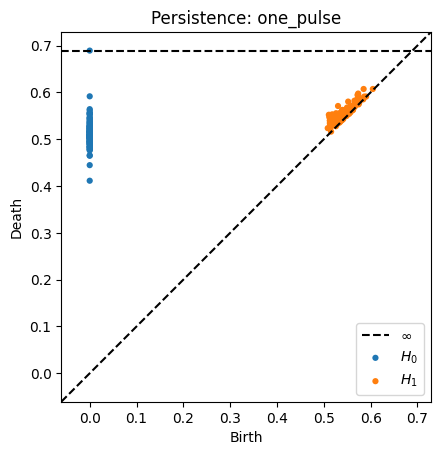

Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)


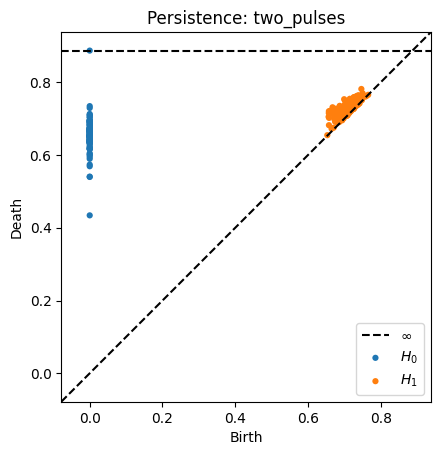

Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)


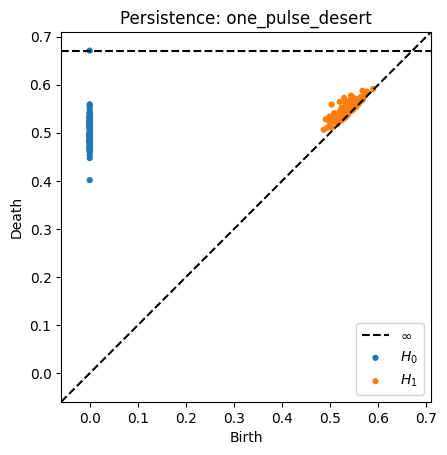

In [37]:
for scenario,X in scenarios.items():
    dist=pairwise_distances(X.astype(bool), metric='jaccard')
    rips=Rips(maxdim=1)
    diagrams=rips.fit_transform(dist, distance_matrix=True)

    plt.figure()
    plot_diagrams(diagrams)
    plt.title(f"Persistence: {scenario}")
    plt.show()


from kmapper.plotlyviz import plotlyviz

for scenario,X in scenarios.items():
    dist=pairwise_distances(X.astype(bool), metric='jaccard')
    bio=individual_biology[ individual_biology['scenario']==scenario ]

    lens=compute_filter('MDS1', X, dist, bio)
    mp=km.KeplerMapper(verbose=0)

    graph=mp.map(lens, X,
        clusterer=km.cluster.DBSCAN(
            eps=eps_vals[scenario],
            min_samples=2,
            metric='jaccard'
        ),
        cover=km.Cover(n_cubes=8,perc_overlap=0.3)
    )

    fig=plotlyviz(graph, title=f"{scenario} Mapper")
    fig.show()